In [13]:
import os
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader

In [14]:
p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "scripts").exists())
sys.path.insert(0, str(repo_root / "scripts"))

In [15]:
from voc_datasets import (
    build_voc_datasets,
    VOC_CLASSES,
    NUM_CLASSES,
    IGNORE_INDEX,
)
from losses import get_ce_loss
from metrics import (
    logits_to_preds,
    compute_pixel_accuracy,
    compute_mean_iou,
    compute_mean_dice,
    compute_per_class_iou,
    compute_per_class_dice,
    compute_per_class_accuracy,
    compute_confusion_matrix,
)
from train_utils import validate_one_epoch
from deeplabv3 import build_deeplabv3

In [16]:
#CONFIG
ROOT = r"c:/Users/Kwame Boateng/Documents/GitHub/semantic-segmentation/Data"
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2

CHECKPOINT_PATH = "checkpoints/deeplab_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [17]:
train_dataset, val_dataset = build_voc_datasets(
    root=ROOT,
    img_size=IMG_SIZE
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Validation samples:", len(val_dataset))

Validation samples: 213


In [18]:
model = build_deeplabv3(num_classes=NUM_CLASSES, pretrained=False).to(device)
criterion = get_ce_loss(ignore_index=IGNORE_INDEX)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)

print("Loaded checkpoint from epoch:", checkpoint["epoch"] + 1)
print("Stored metrics:", checkpoint["metrics"])

Loaded checkpoint from epoch: 17
Stored metrics: {'loss': 0.546868514007246, 'pixel_acc': 0.8929911924639778, 'mean_iou': 0.36859838867411365, 'mean_dice': 0.42836344605880167}


In [19]:
val_metrics = validate_one_epoch(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

Validation metrics:
loss: 0.5469
pixel_acc: 0.8930
mean_iou: 0.3686
mean_dice: 0.4284


In [20]:
def show_prediction(image, true_mask, pred_mask, class_names, ignore_index=255):
    image = image.permute(1, 2, 0).cpu().numpy()

    true_mask = true_mask.cpu().numpy().copy()
    pred_mask = pred_mask.cpu().numpy().copy()

    true_mask_vis = true_mask.copy()
    pred_mask_vis = pred_mask.copy()

    true_mask_vis[true_mask_vis == ignore_index] = 0

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_vis, cmap="tab20", vmin=0, vmax=len(class_names) - 1)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_vis, cmap="tab20", vmin=0, vmax=len(class_names) - 1)
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

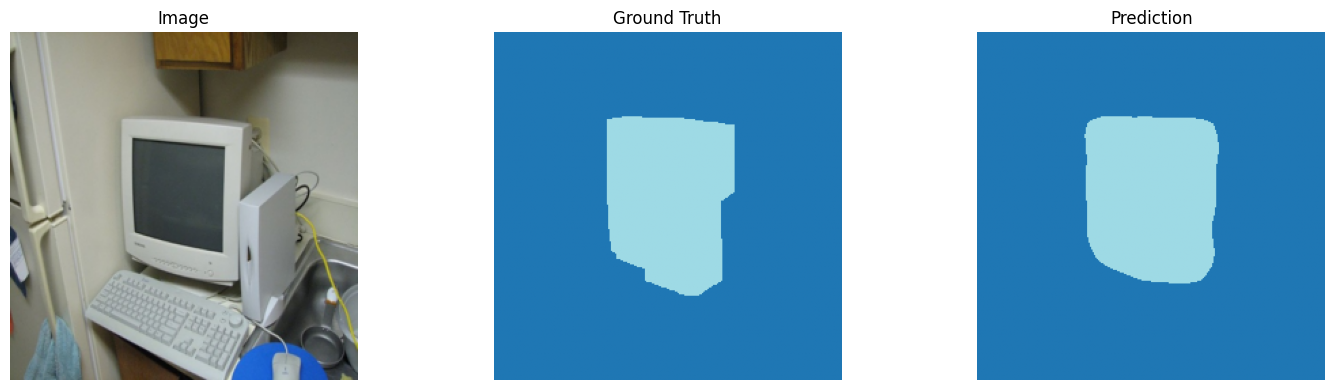

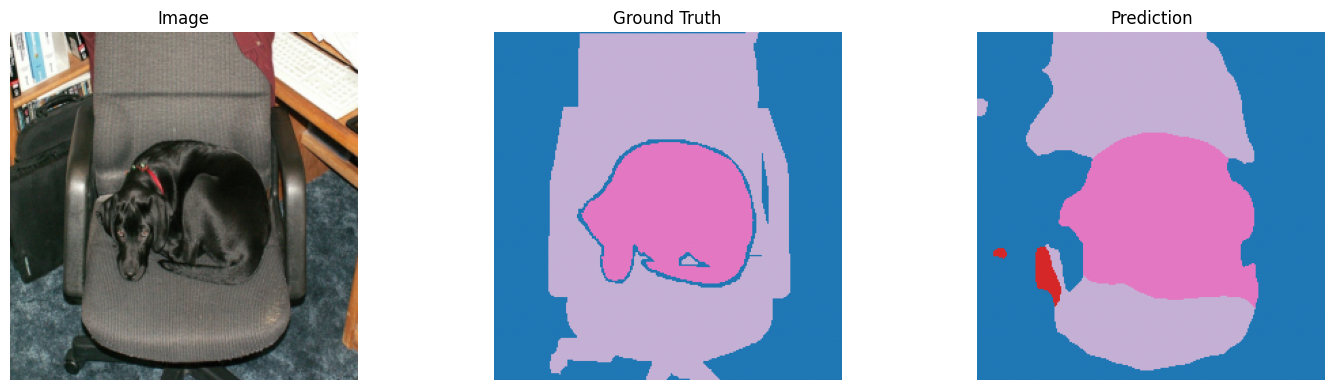

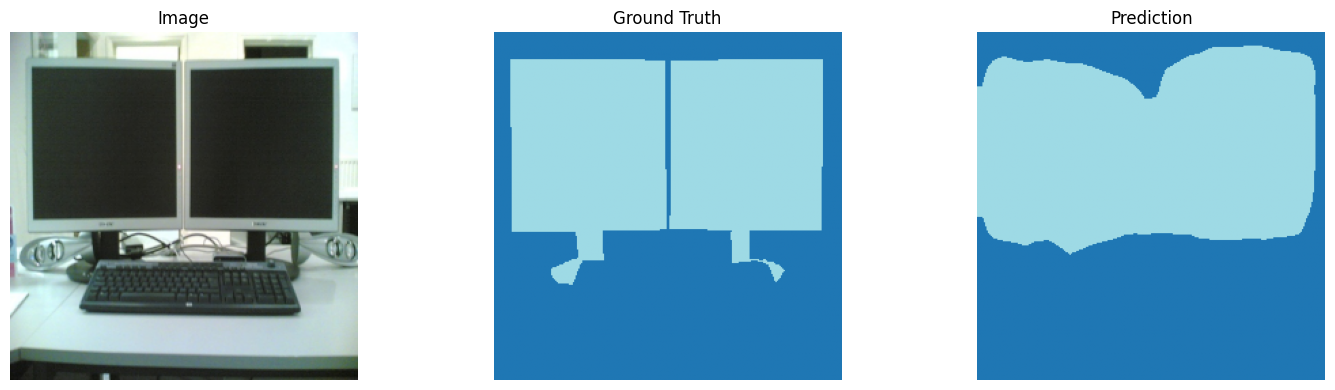

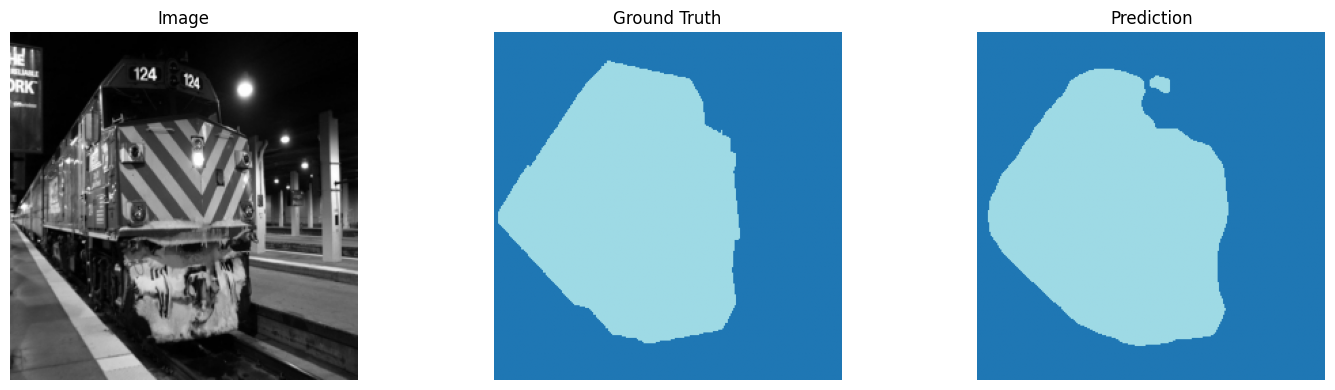

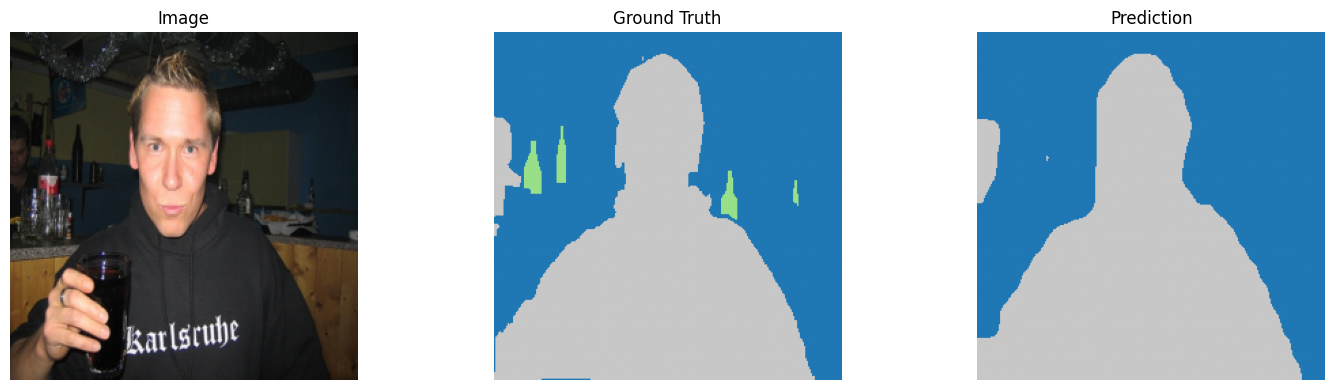

In [21]:
model.eval()

num_examples = 5
shown = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = logits_to_preds(logits)

        for i in range(images.size(0)):
            show_prediction(images[i], masks[i], preds[i], VOC_CLASSES, IGNORE_INDEX)
            shown += 1
            if shown >= num_examples:
                break

        if shown >= num_examples:
            break

In [22]:
model.eval()

all_preds = []
all_targets = []
all_images = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = logits_to_preds(logits)

        all_preds.append(preds.cpu())
        all_targets.append(masks.cpu())
        all_images.append(images.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_images = torch.cat(all_images, dim=0)

print("all_preds shape:", all_preds.shape)
print("all_targets shape:", all_targets.shape)
print("all_images shape:", all_images.shape)

all_preds shape: torch.Size([213, 256, 256])
all_targets shape: torch.Size([213, 256, 256])
all_images shape: torch.Size([213, 3, 256, 256])


In [23]:
per_class_iou = compute_per_class_iou(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

per_class_dice = compute_per_class_dice(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

per_class_acc = compute_per_class_accuracy(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print(f"{'Class':<15} {'IoU':>10} {'Dice':>10} {'Acc':>10}")
for i, name in enumerate(VOC_CLASSES):
    iou = per_class_iou[i].item() if not torch.isnan(per_class_iou[i]) else float("nan")
    dice = per_class_dice[i].item() if not torch.isnan(per_class_dice[i]) else float("nan")
    acc = per_class_acc[i].item() if not torch.isnan(per_class_acc[i]) else float("nan")
    print(f"{name:<15} {iou:>10.4f} {dice:>10.4f} {acc:>10.4f}")

Class                  IoU       Dice        Acc
background          0.8982     0.9464     0.9769
aeroplane           0.6984     0.8224     0.7837
bicycle             0.2521     0.4027     0.5392
bird                0.6720     0.8039     0.7305
boat                0.4032     0.5747     0.4605
bottle              0.5779     0.7325     0.6076
bus                 0.8197     0.9009     0.9274
car                 0.7586     0.8627     0.8491
cat                 0.6428     0.7826     0.8763
chair               0.2437     0.3919     0.2771
cow                 0.4300     0.6014     0.5612
diningtable         0.2398     0.3868     0.2532
dog                 0.4305     0.6019     0.5604
horse               0.5671     0.7237     0.7244
motorbike           0.6322     0.7747     0.7356
person              0.7945     0.8855     0.8791
pottedplant         0.1936     0.3244     0.2002
sheep               0.1001     0.1820     0.1002
sofa                0.2067     0.3425     0.3093
train               

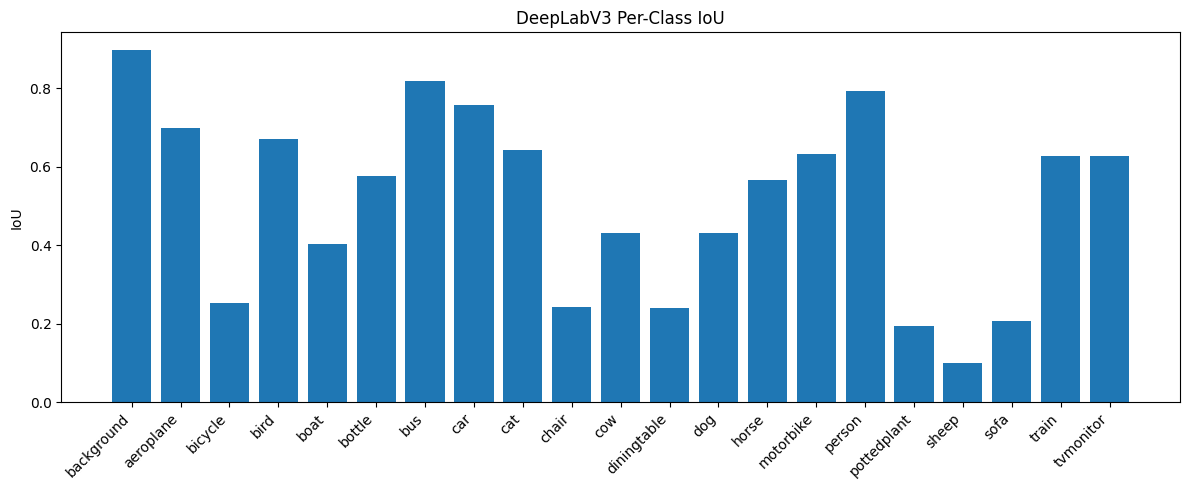

In [24]:
iou_values = per_class_iou.cpu().numpy()

plt.figure(figsize=(12, 5))
plt.bar(range(NUM_CLASSES), np.nan_to_num(iou_values, nan=0.0))
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=45, ha="right")
plt.ylabel("IoU")
plt.title("DeepLabV3 Per-Class IoU")
plt.tight_layout()
plt.show()

In [25]:
cm = compute_confusion_matrix(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("Confusion matrix shape:", cm.shape)
cm

Confusion matrix shape: torch.Size([21, 21])


tensor([[9583124,   12164,   29117,    6727,    7650,    2633,   11420,    6681,
           17799,    3540,    9260,    7743,    2315,    7252,   12662,   47033,
            2155,      37,   25030,   10037,    5741],
        [  11754,   95049,       0,       0,       0,       0,    8460,       0,
               0,       0,       0,       0,       0,      25,     211,    3624,
               0,       0,       0,    2159,       0],
        [   8072,      65,   15511,       0,       0,       0,       0,       0,
               0,       0,       0,       0,       0,       0,    3699,    1369,
               0,      51,       0,       0,       0],
        [  24313,     369,       0,   92366,       0,       3,       0,       0,
             374,       0,       0,       0,     926,    5944,      35,    2107,
               0,       0,       0,       0,       0],
        [  26834,    1237,    2009,       0,   27625,       0,    2280,       0,
               0,       0,       0,       0,       

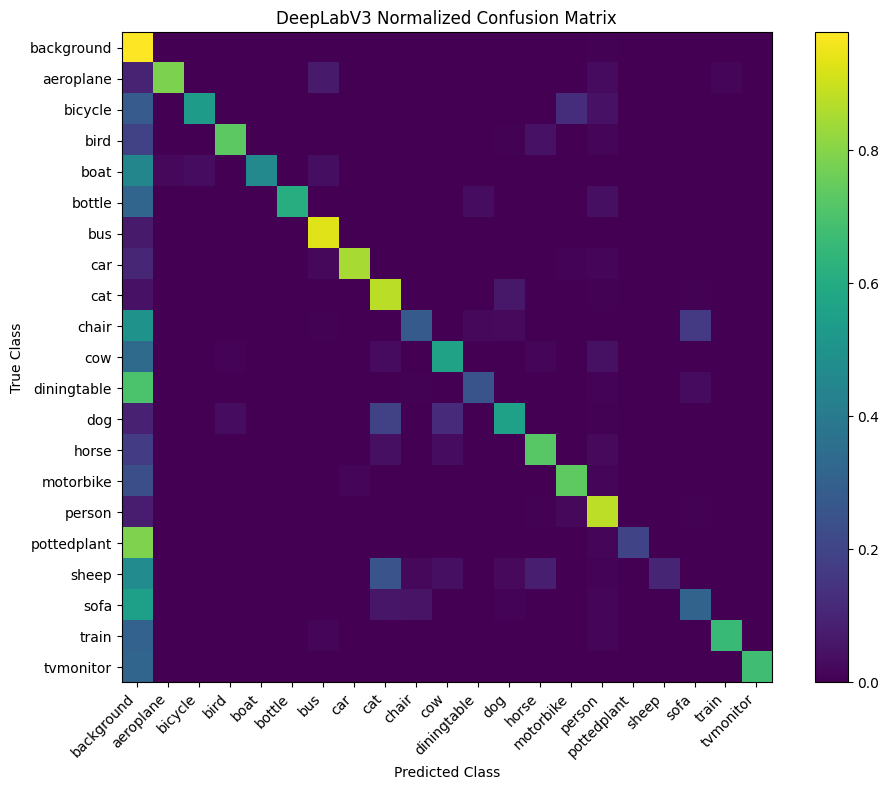

In [26]:
cm_np = cm.cpu().numpy().astype(np.float64)
row_sums = cm_np.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_np, row_sums, where=row_sums != 0)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("DeepLabV3 Normalized Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), VOC_CLASSES)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [27]:
def compute_sample_iou(pred_mask, true_mask, num_classes, ignore_index=255):
    return compute_mean_iou(
        pred_mask.unsqueeze(0),
        true_mask.unsqueeze(0),
        num_classes=num_classes,
        ignore_index=ignore_index,
    )

def compute_sample_dice(pred_mask, true_mask, num_classes, ignore_index=255):
    return compute_mean_dice(
        pred_mask.unsqueeze(0),
        true_mask.unsqueeze(0),
        num_classes=num_classes,
        ignore_index=ignore_index,
    )

sample_scores = []

for i in range(len(all_preds)):
    miou = compute_sample_iou(all_preds[i], all_targets[i], NUM_CLASSES, IGNORE_INDEX)
    mdice = compute_sample_dice(all_preds[i], all_targets[i], NUM_CLASSES, IGNORE_INDEX)

    sample_scores.append({
        "index": i,
        "mean_iou": miou,
        "mean_dice": mdice,
    })

sample_scores = sorted(sample_scores, key=lambda x: x["mean_iou"], reverse=True)

print("Top sample:", sample_scores[0])
print("Worst sample:", sample_scores[-1])

Top sample: {'index': 184, 'mean_iou': 0.9910829067230225, 'mean_dice': 0.9955205917358398}
Worst sample: {'index': 99, 'mean_iou': 0.09327007085084915, 'mean_dice': 0.13585522770881653}


Best examples:
{'index': 184, 'mean_iou': 0.9910829067230225, 'mean_dice': 0.9955205917358398}


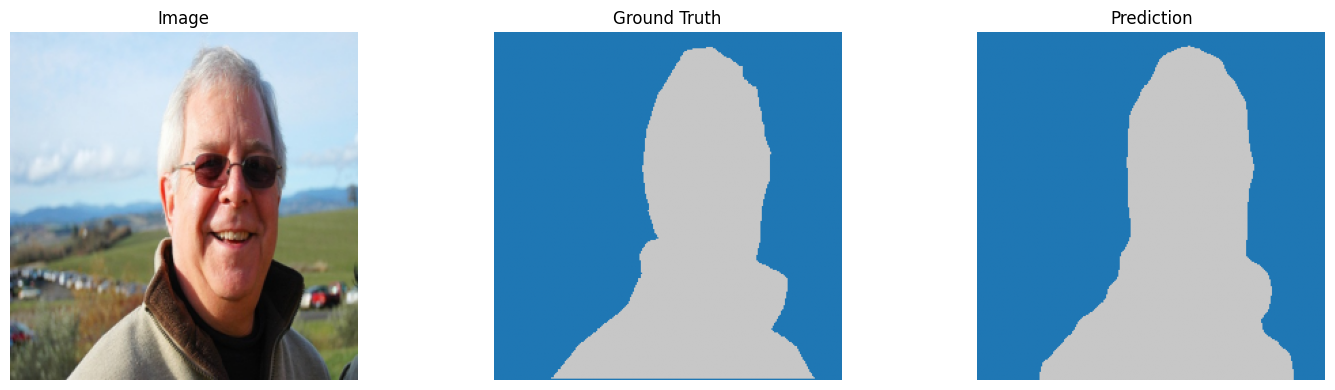

{'index': 154, 'mean_iou': 0.979304313659668, 'mean_dice': 0.989527702331543}


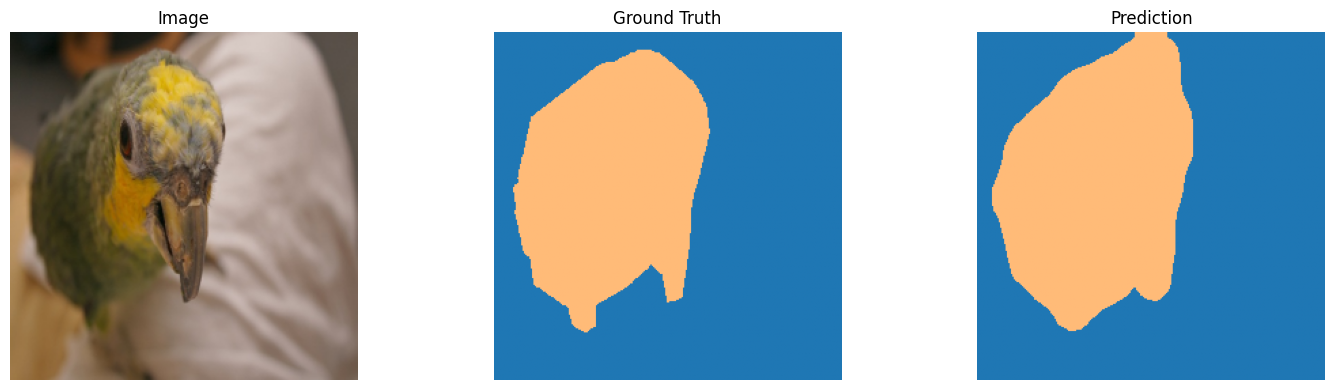

{'index': 19, 'mean_iou': 0.9782520532608032, 'mean_dice': 0.9889736771583557}


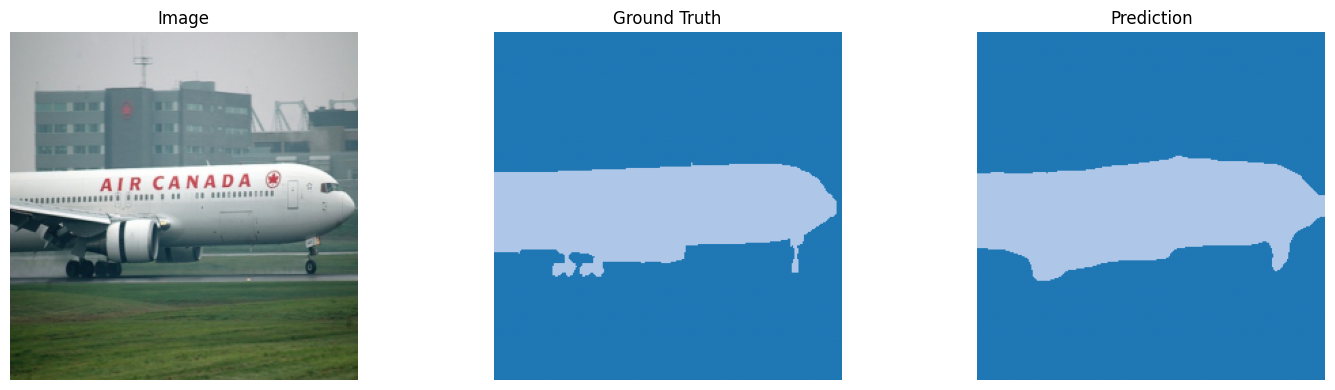

In [28]:
top_k = 3

print("Best examples:")
for entry in sample_scores[:top_k]:
    idx = entry["index"]
    print(entry)
    show_prediction(all_images[idx], all_targets[idx], all_preds[idx], VOC_CLASSES, IGNORE_INDEX)

Worst examples:
{'index': 180, 'mean_iou': 0.12601685523986816, 'mean_dice': 0.14042311906814575}


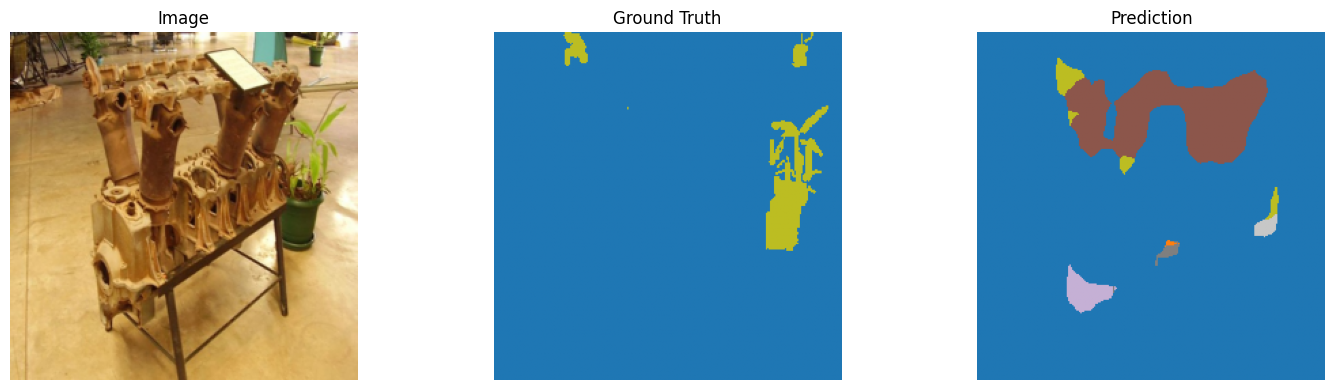

{'index': 108, 'mean_iou': 0.12017393112182617, 'mean_dice': 0.1305374652147293}


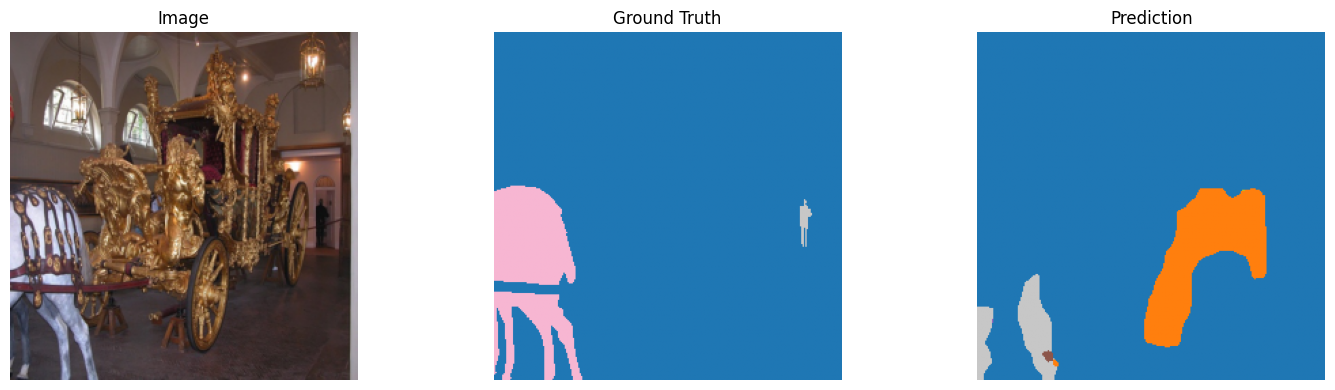

{'index': 99, 'mean_iou': 0.09327007085084915, 'mean_dice': 0.13585522770881653}


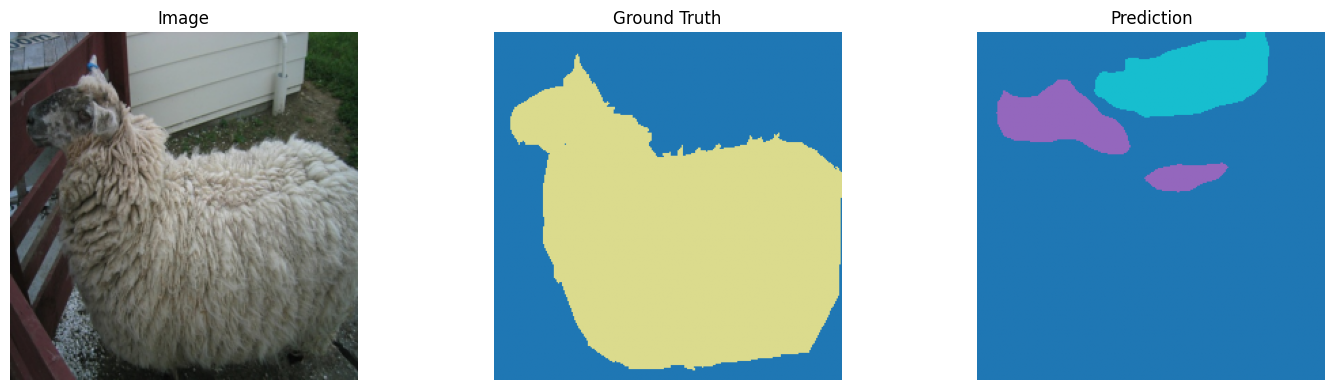

In [29]:
top_k = 3

print("Worst examples:")
for entry in sample_scores[-top_k:]:
    idx = entry["index"]
    print(entry)
    show_prediction(all_images[idx], all_targets[idx], all_preds[idx], VOC_CLASSES, IGNORE_INDEX)

In [30]:
overall_pixel_acc = compute_pixel_accuracy(all_preds, all_targets, IGNORE_INDEX)
overall_miou = compute_mean_iou(all_preds, all_targets, NUM_CLASSES, IGNORE_INDEX)
overall_mdice = compute_mean_dice(all_preds, all_targets, NUM_CLASSES, IGNORE_INDEX)

print("DeepLabV3 Final Evaluation Summary")
print(f"Pixel Accuracy: {overall_pixel_acc:.4f}")
print(f"Mean IoU: {overall_miou:.4f}")
print(f"Mean Dice: {overall_mdice:.4f}")

DeepLabV3 Final Evaluation Summary
Pixel Accuracy: 0.8935
Mean IoU: 0.5150
Mean Dice: 0.6469


In [31]:
from metrics import compute_hd95

per_class_hd95 = compute_hd95(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print(f"{'Class':<15} {'HD95':>10}")
for i, name in enumerate(VOC_CLASSES):
    value = per_class_hd95[i].item() if not torch.isnan(per_class_hd95[i]) else float("nan")
    print(f"{name:<15} {value:>10.4f}")

Class                 HD95
background         15.3948
aeroplane          28.7726
bicycle            47.8649
bird               54.4346
boat               35.7022
bottle             69.5907
bus                18.4697
car                57.5120
cat                23.6250
chair              85.5266
cow                33.0971
diningtable        66.8086
dog                44.7396
horse              25.2254
motorbike          34.2900
person             34.4491
pottedplant        69.4934
sheep              54.9843
sofa               56.2418
train              57.3392
tvmonitor          14.4543
